In [ ]:
!pip install -q transformers datasets peft accelerate bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.7 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login
login()

In [ ]:
import torch
import json
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer

In [ ]:
with open("/content/it_support_sft_dataset.json", "r") as f:
    data = json.load(f)

dataset = Dataset.from_list(data)
dataset

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 169
})

In [ ]:
def format_example(example):
    return {
        "text": f"""### Instruction:
{example['instruction']}

### Response:
{example['output']}"""
    }

dataset = dataset.map(format_example)

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

In [ ]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


In [ ]:
training_args = TrainingArguments(
    output_dir="/content/support-model",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=False,
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    report_to="none"
)

In [ ]:
def formatting_func(example):
    return example["text"]

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    args=training_args,
    formatting_func=formatting_func,
    processing_class=tokenizer,   # ✅ NEW FIX
)

Applying formatting function to train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,1.728927
20,1.637460
30,1.519361
40,1.427896
50,1.465556
60,1.445152
70,1.308354
80,1.318908


TrainOutput(global_step=86, training_loss=1.4635491371154785, metrics={'train_runtime': 310.4997, 'train_samples_per_second': 1.089, 'train_steps_per_second': 0.277, 'total_flos': 802617987784704.0, 'train_loss': 1.4635491371154785})

In [ ]:
trainer.model.save_pretrained("/content/support-model")
tokenizer.save_pretrained("/content/support-model")

('/content/support-model/tokenizer_config.json',
 '/content/support-model/chat_template.jinja',
 '/content/support-model/tokenizer.json')

In [ ]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model=trainer.model,
    tokenizer=tokenizer,
)

prompt = """### Instruction:
My printer is not working

### Response:
"""

result = pipe(
    prompt,
    max_new_tokens=300,   # 🔥 increase
    temperature=0.7,
    top_p=0.9,
    do_sample=True
)

print(result[0]["generated_text"])

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'top_p', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=300) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
My printer is not working

### Response:
If your printer is not working, the first thing to check is the printer driver. Here is how to troubleshoot:

**Check the printer driver**
1. Open the Control Panel.
2. Click **Add a program**.
3. In the Add a program dialog box, click **Start**.
4. In the Start search box, type **Printers**.
5. In the results, select the **Windows Printers and drivers** option.
6. Click **Add**.
7. In the Add Printer Wizard, select your printer model from the list and click Next.
8. If the driver is not installed, the wizard will automatically download and install the driver for you.
9. If the driver is already installed, the wizard will automatically update it.

**Check the printer settings**
1. In the Control Panel, click **System**.
2. Click **Printers**.
3. Select your printer and check the following:
   - **Print server**: Is it set to use the same computer as the printer?
   - **Port**: Is the printer connected to a valid port?
   - **Def

In [ ]:
import pandas as pd

results = []

In [ ]:
import itertools

# Best 2 values per hyperparameter → 2×2×2×2 = 16 combinations total
learning_rates = [2e-4, 1e-4]
epochs_list    = [1, 2]
r_values       = [8, 16]
alpha_values   = [16, 32]

# We need the base model name and bnb_config from earlier cells
# Re-load the base (non-PEFT) model fresh for each combination to avoid stacking adapters

for lr, ep, r, alpha in itertools.product(
    learning_rates, epochs_list, r_values, alpha_values
):
    print(f"\n{'='*60}")
    print(f"Running: lr={lr}, epochs={ep}, r={r}, alpha={alpha}")
    print(f"{'='*60}")

    # ✅ FIX: Reload the BASE model fresh each iteration — prevents adapter stacking
    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto"
    )

    # LoRA config with current hyperparameters
    lora_config = LoraConfig(
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    # ✅ FIX: Apply PEFT to the fresh base model, not the previous iteration's model
    peft_model = get_peft_model(base_model, lora_config)

    training_args = TrainingArguments(
        output_dir="/content/exp",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=2,
        num_train_epochs=ep,
        learning_rate=lr,
        fp16=False,
        bf16=False,
        logging_steps=10,
        save_strategy="no",
        report_to="none"
    )

    trainer = SFTTrainer(
        model=peft_model,
        train_dataset=dataset,
        args=training_args,
        formatting_func=lambda x: x["text"],
        processing_class=tokenizer,
    )

    trainer.train()

    # ✅ FIX: Build pipeline from the current trained model, not the stale one built before the loop
    current_pipe = pipeline(
        "text-generation",
        model=trainer.model,
        tokenizer=tokenizer,
    )

    output = current_pipe(prompt, max_new_tokens=200)[0]["generated_text"]

    results.append({
        "lr": lr,
        "epochs": ep,
        "r": r,
        "alpha": alpha,
        "output_sample": output[:200]
    })

    # Free memory before next iteration
    del base_model, peft_model, trainer, current_pipe
    torch.cuda.empty_cache()



Running: lr=0.0002, epochs=1, r=8, alpha=16


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Applying formatting function to train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

...

Adding EOS to train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,1.757186
20,1.709816
30,1.629100
40,1.550249
50,1.594938
60,1.576501
70,1.431801
80,1.441757


Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
df = pd.DataFrame(results)
df.to_csv("/content/experiment_results.csv", index=False)
df

,lr,epochs,r,alpha,output_sample
0,0.0002,1,8,16,### Instruction:\nMy printer is not working\n\...
1,0.0002,1,8,32,### Instruction:\nMy printer is not working\n\...
2,0.0002,1,16,16,### Instruction:\nMy printer is not working\n\...
3,0.0002,1,16,32,### Instruction:\nMy printer is not working\n\...
4,0.0002,2,8,16,### Instruction:\nMy printer is not working\n\...
5,0.0002,2,8,32,### Instruction:\nMy printer is not working\n\...
6,0.0002,2,16,16,### Instruction:\nMy printer is not working\n\...
7,0.0002,2,16,32,### Instruction:\nMy printer is not working\n\...
8,0.0001,1,8,16,### Instruction:\nMy printer is not working\n\...
9,0.0001,1,8,32,### Instruction:\nMy printer is not working\n\...


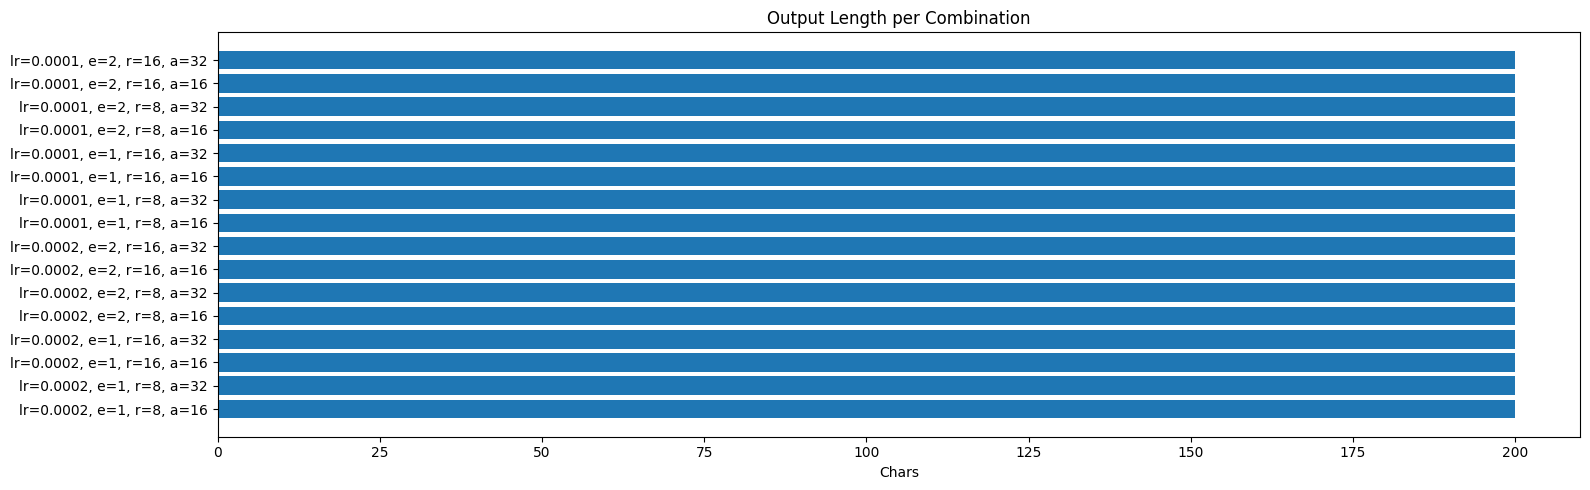

In [ ]:
import matplotlib.pyplot as plt

labels = [f"lr={r['lr']}, e={r['epochs']}, r={r['r']}, a={r['alpha']}" for r in results]
output_lens = [len(r['output_sample']) for r in results]

plt.figure(figsize=(16,5))
plt.barh(labels, output_lens)
plt.title("Output Length per Combination")
plt.xlabel("Chars")
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Applying formatting function to train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/169 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,1.727463
20,1.634774
30,1.515570
40,1.428099
50,1.463589
60,1.445787
70,1.308579
80,1.318017


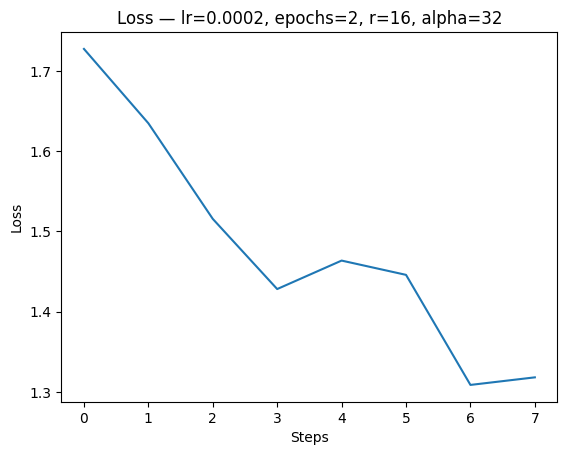

In [ ]:
# Rerun only the best combo you want to inspect
lr, ep, r, alpha = 2e-4, 2, 16, 32  # change to whichever combo you want

base_model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")
lora_config = LoraConfig(r=r, lora_alpha=alpha, target_modules=["q_proj", "v_proj"], lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
peft_model = get_peft_model(base_model, lora_config)

training_args = TrainingArguments(output_dir="/content/exp", per_device_train_batch_size=2, gradient_accumulation_steps=2, num_train_epochs=ep, learning_rate=lr, fp16=False, bf16=False, logging_steps=10, save_strategy="no", report_to="none")
trainer = SFTTrainer(model=peft_model, train_dataset=dataset, args=training_args, formatting_func=lambda x: x["text"], processing_class=tokenizer)
trainer.train()

# Now plot
import matplotlib.pyplot as plt
loss_vals = [x["loss"] for x in trainer.state.log_history if "loss" in x]
plt.plot(loss_vals)
plt.title(f"Loss — lr={lr}, epochs={ep}, r={r}, alpha={alpha}")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.show()

In [ ]:
from transformers import pipeline


pipe = pipeline(
    "text-generation",
    model=peft_model, # Using the peft_model from the last training run
    tokenizer=tokenizer,
)


user_query = "Im having problem creating a PPT. WHat should I do?"

prompt_template = f"""### Instruction:
{user_query}

### Response:
"""


result = pipe(
    prompt_template,
    max_new_tokens=500, # Increased tokens to prevent truncation
    temperature=0.7,
    top_p=0.9,
    do_sample=True
)

print(result[0]["generated_text"])

Both `max_new_tokens` (=500) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Instruction:
Im having problem creating a PPT. WHat should I do?

### Response:
If you are having trouble creating a PowerPoint presentation, the following troubleshooting steps can help:

1. **Verify PowerPoint is installed and configured correctly**: Make sure PowerPoint is installed and configured correctly on your computer. Check the **Microsoft PowerPoint** section in the **Start** menu.

2. **Verify PowerPoint is running correctly**: Make sure PowerPoint is running and is in the **Start** or **Run** dialog box.

3. **Restart PowerPoint**: Close all PowerPoint instances and restart the application.

4. **Check the PowerPoint settings**: Open PowerPoint, go to **File** > **Settings**. Check the **General** tab for any errors.

5. **Check the installation package**: If you downloaded the PowerPoint from Microsoft, verify the installation package was correctly installed.

6. **Verify the version of PowerPoint**: Check the **Help** tab of PowerPoint for the current version number.